# EXPLORASI DATA ANALISIS

In [2]:
import pandas as pd
import numpy as nP

In [3]:
df = pd.read_excel ('DATA TUGAS ML BU LAILA.xlsx')

In [4]:
print(df)

        KABUPATEN/KOTA   KEMISKINAN      PDRB    IPM   TPT    RLS
0             Simeulue        17.92   2935.10  68.06  5.85   9.81
1         Aceh Singkil        19.15   3202.51  70.14  6.84   8.70
2         Aceh Selatan        12.10   6963.46  68.44  4.73   8.91
3        Aceh Tenggara        12.45   6257.95  71.05  5.00  10.09
4           Aceh Timur        13.39  13803.09  69.32  8.03   8.47
..                 ...          ...       ...    ...   ...    ...
474      Teluk Wondama        28.90   1749.73  61.67  2.77   7.27
475      Teluk Bintuni        28.24  39540.59  66.00  3.52   8.51
476          Manokwari        18.73  10647.55  73.21  5.97   8.54
477  Manokwari Selatan        27.80    927.48  61.55   NaN   6.96
478   Pegunungan Arfak        32.29    308.51  57.82   NaN   5.51

[479 rows x 6 columns]


In [5]:
df.columns

Index(['KABUPATEN/KOTA', ' KEMISKINAN', 'PDRB', 'IPM', 'TPT', 'RLS'], dtype='object')

In [6]:
df.shape

(479, 6)

### Menampilkan 5 baris pertama pada data


In [7]:
df.head()

,KABUPATEN/KOTA,KEMISKINAN,PDRB,IPM,TPT,RLS
0,Simeulue,17.92,2935.10,68.06,5.85,9.81
1,Aceh Singkil,19.15,3202.51,70.14,6.84,8.70
2,Aceh Selatan,12.10,6963.46,68.44,4.73,8.91
3,Aceh Tenggara,12.45,6257.95,71.05,5.00,10.09
4,Aceh Timur,13.39,13803.09,69.32,8.03,8.47


### Tipe data tiap kolom dan jumlah missing value

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   KABUPATEN/KOTA  479 non-null    object 
 1    KEMISKINAN     479 non-null    float64
 2   PDRB            479 non-null    float64
 3   IPM             479 non-null    float64
 4   TPT             472 non-null    float64
 5   RLS             479 non-null    float64
dtypes: float64(5), object(1)
memory usage: 22.6+ KB


#####  Hanya kolom TPT yang punya 7 missing value (karena 479 total baris − 472 non-null = 7)

### Statistik Deskriptif (mean,std,min,max,dll)

In [9]:
df.describe ()

,KEMISKINAN,PDRB,IPM,TPT,RLS
count,479.000000,479.000000,479.000000,472.000000,479.000000
mean,10.381169,42317.269290,72.061106,4.493538,8.786701
std,5.523410,89799.221178,5.087397,2.027737,1.382219
min,2.270000,308.510000,57.820000,0.750000,5.070000
25%,6.455000,8012.450000,68.635000,2.857500,7.810000
50%,9.160000,18025.680000,71.210000,4.125000,8.560000
75%,13.140000,38318.760000,74.530000,5.767500,9.560000
max,32.290000,859832.000000,88.280000,11.650000,13.040000


### Check Missing value

In [10]:
df.isna().sum()

KABUPATEN/KOTA    0
 KEMISKINAN       0
PDRB              0
IPM               0
TPT               7
RLS               0
dtype: int64

### Mengatasi missing value

#### Missing value diisi dengan nilai median

In [11]:
median_tpt = df["TPT"].median()
df["TPT"] = df["TPT"].fillna(median_tpt)
df

,KABUPATEN/KOTA,KEMISKINAN,PDRB,IPM,TPT,RLS
0,Simeulue,17.92,2935.10,68.06,5.850,9.81
1,Aceh Singkil,19.15,3202.51,70.14,6.840,8.70
2,Aceh Selatan,12.10,6963.46,68.44,4.730,8.91
3,Aceh Tenggara,12.45,6257.95,71.05,5.000,10.09
4,Aceh Timur,13.39,13803.09,69.32,8.030,8.47
...,...,...,...,...,...,...
474,Teluk Wondama,28.90,1749.73,61.67,2.770,7.27
475,Teluk Bintuni,28.24,39540.59,66.00,3.520,8.51
476,Manokwari,18.73,10647.55,73.21,5.970,8.54
477,Manokwari Selatan,27.80,927.48,61.55,4.125,6.96


### Check outliers

In [12]:
import scipy.stats as stats
import numpy as np

In [13]:
# Pilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns

In [14]:
# MENAMPILKAN JUMLAH OUTLIER 
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    fence_low = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr

    outliers = df.loc[(df[col] < fence_low) | (df[col] > fence_high)]

    print(f"{col} → jumlah outlier: {len(outliers)}")

 KEMISKINAN → jumlah outlier: 17
PDRB → jumlah outlier: 51
IPM → jumlah outlier: 16
TPT → jumlah outlier: 4
RLS → jumlah outlier: 4


### WINSORING (Mengganti outlier dengan batas bawah/atas)

In [15]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

In [16]:
import numpy as np

# Mengecek outlier kembali setelah winsorizing
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Cari outlier
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} → jumlah outlier: {len(outliers)}")

 KEMISKINAN → jumlah outlier: 0
PDRB → jumlah outlier: 0
IPM → jumlah outlier: 0
TPT → jumlah outlier: 0
RLS → jumlah outlier: 0


### CHECK DUPLICATES

In [17]:
df.duplicated().sum()

np.int64(0)

Tidak ada duplikat pada data

In [18]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Memilih kolom numerik
numeric_cols = df.select_dtypes(include='number').columns

# Inisialisasi scaler
scaler = StandardScaler()

# Melakukan standarisasi
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Menampilkan hasil
df_scaled

,KABUPATEN/KOTA,KEMISKINAN,PDRB,IPM,TPT,RLS
0,Simeulue,1.514038,-0.959463,-0.798981,0.687955,0.746935
1,Aceh Singkil,1.756259,-0.948937,-0.380056,1.185504,-0.061439
2,Aceh Selatan,0.367919,-0.800895,-0.722447,0.125072,0.091497
3,Aceh Tenggara,0.436844,-0.828666,-0.196777,0.260767,0.950850
4,Aceh Timur,0.621956,-0.531667,-0.545209,1.783568,-0.228940
...,...,...,...,...,...,...
474,Teluk Wondama,2.547417,-1.006122,-2.085966,-0.859974,-1.102858
475,Teluk Bintuni,2.547417,0.481437,-1.213877,-0.483043,-0.199809
476,Manokwari,1.673550,-0.655878,0.238260,0.748264,-0.177961
477,Manokwari Selatan,2.547417,-1.038489,-2.110134,-0.178986,-1.328620


## VISUALISASI DATA


In [22]:

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style 
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [27]:
df_handled = df.copy()

In [28]:
#Ringkasan statistik setelah handling missing & outlier
print("=== DATA SETELAH PREPROCESSING (479 baris) ===")
df_handled.describe().round(2)

=== DATA SETELAH PREPROCESSING (479 baris) ===


,KEMISKINAN,PDRB,IPM,TPT,RLS
count,479.00,479.00,479.00,479.00,479.00
mean,10.23,27309.87,72.03,4.48,8.78
std,5.08,25431.16,4.97,1.99,1.37
min,2.27,308.51,59.79,0.75,5.18
25%,6.46,8012.45,68.63,2.88,7.81
50%,9.16,18025.68,71.21,4.12,8.56
75%,13.14,38318.76,74.53,5.76,9.56
max,23.17,83778.23,83.37,10.07,12.19


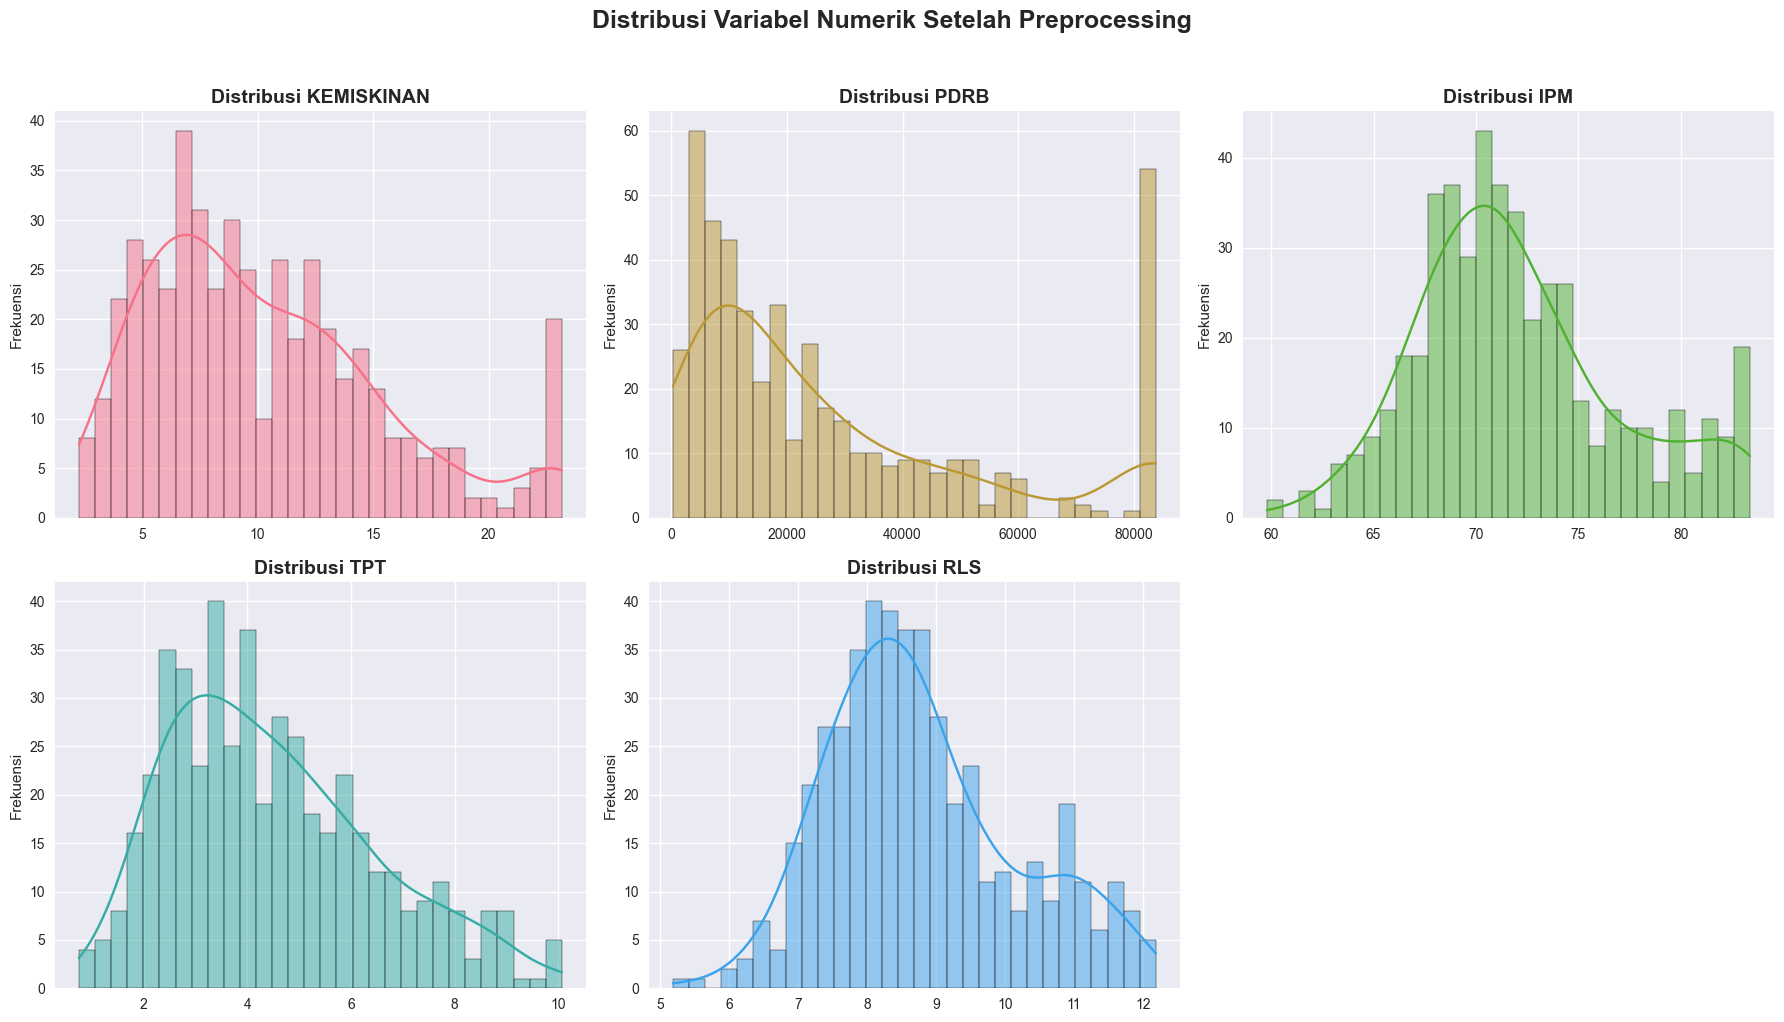

In [29]:
#  Distribusi setiap variabel numerik (Histogram + KDE)
numeric_cols = [' KEMISKINAN', 'PDRB', 'IPM', 'TPT', 'RLS']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_handled, x=col, kde=True, ax=axes[i], bins=30, color=sns.color_palette()[i])
    axes[i].set_title(f'Distribusi {col.strip()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan subplot kosong
axes[5].axis('off')

plt.suptitle('Distribusi Variabel Numerik Setelah Preprocessing', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

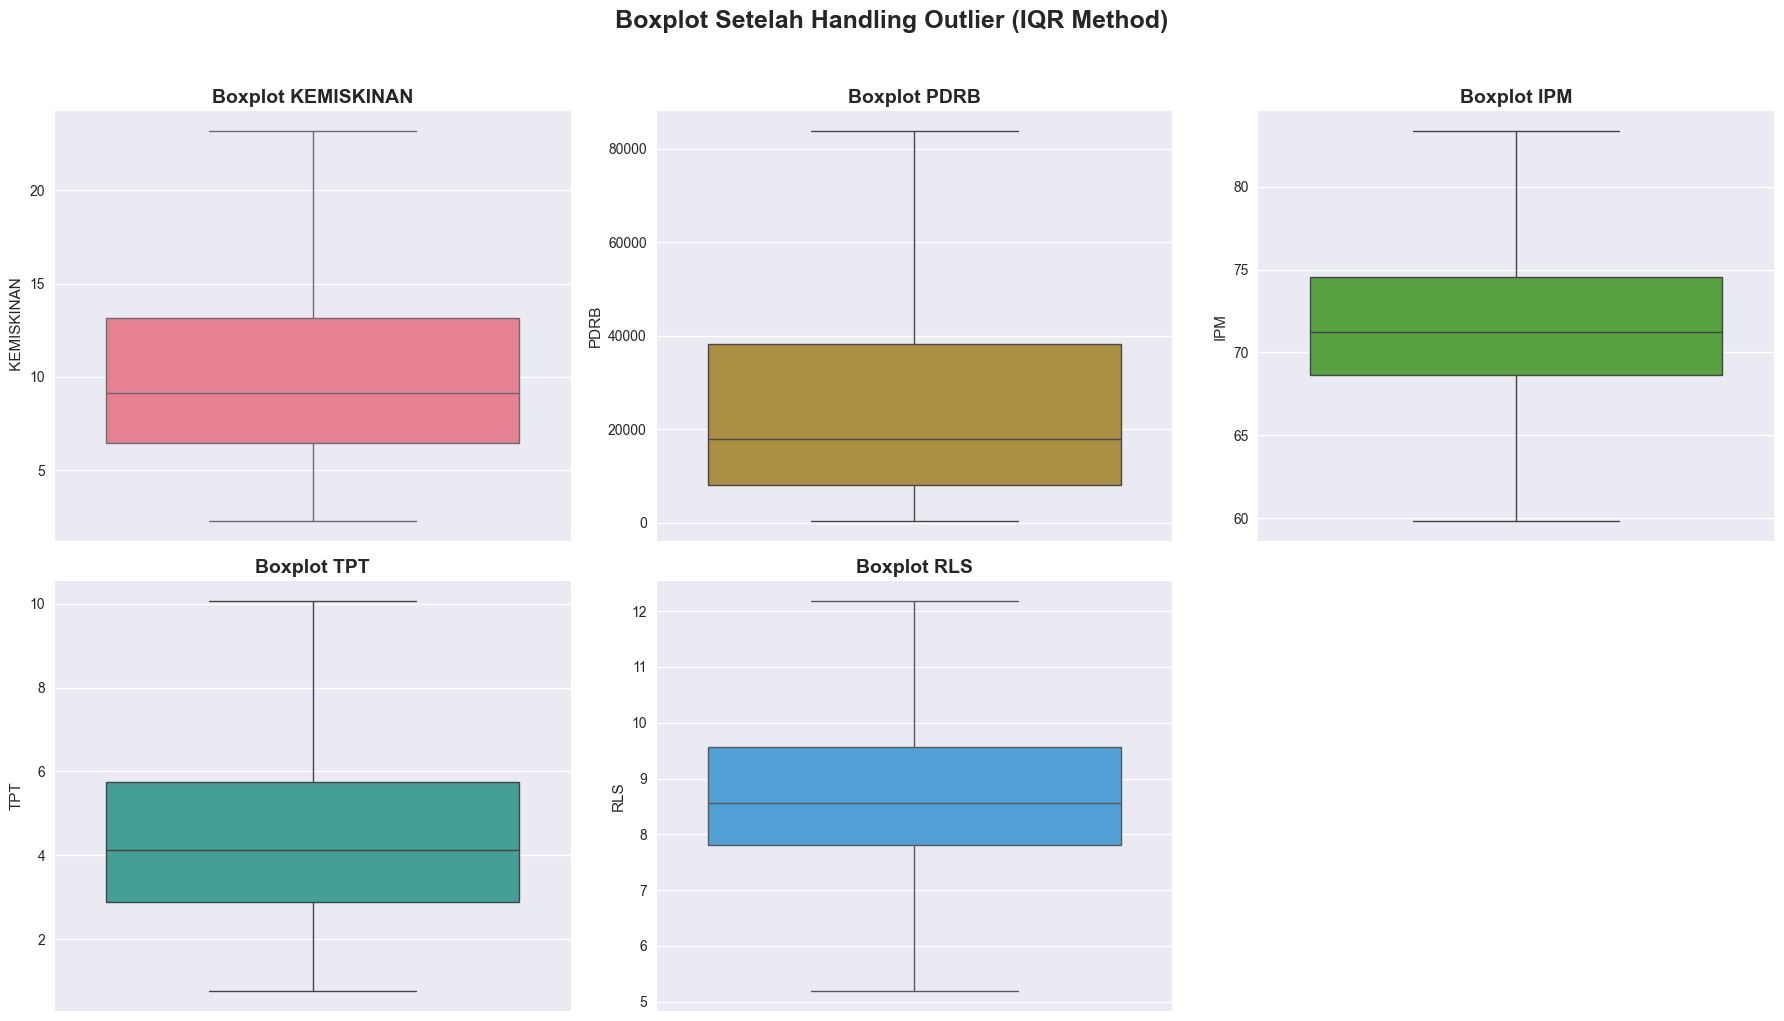

In [30]:
#  Boxplot untuk melihat outlier (setelah di-handle)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_handled[col], ax=axes[i], color=sns.color_palette()[i])
    axes[i].set_title(f'Boxplot {col.strip()}', fontsize=14, fontweight='bold')

axes[5].axis('off')
plt.suptitle('Boxplot Setelah Handling Outlier (IQR Method)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

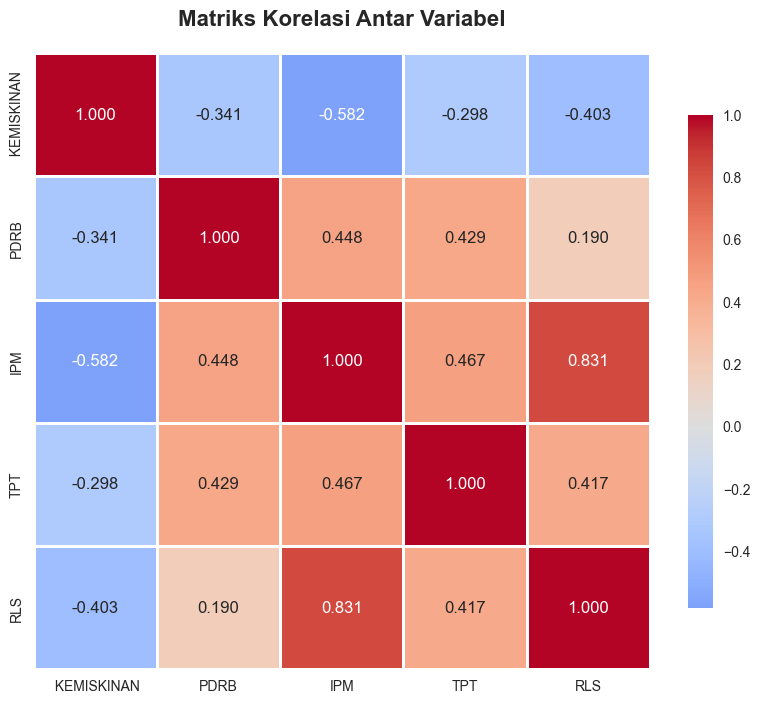

In [31]:
# Heatmap Korelasi
plt.figure(figsize=(10, 8))
corr = df_handled[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=1, fmt='.3f',
            square=True, cbar_kws={"shrink": .8})
plt.title('Matriks Korelasi Antar Variabel', fontsize=16, fontweight='bold', pad=20)
plt.show()

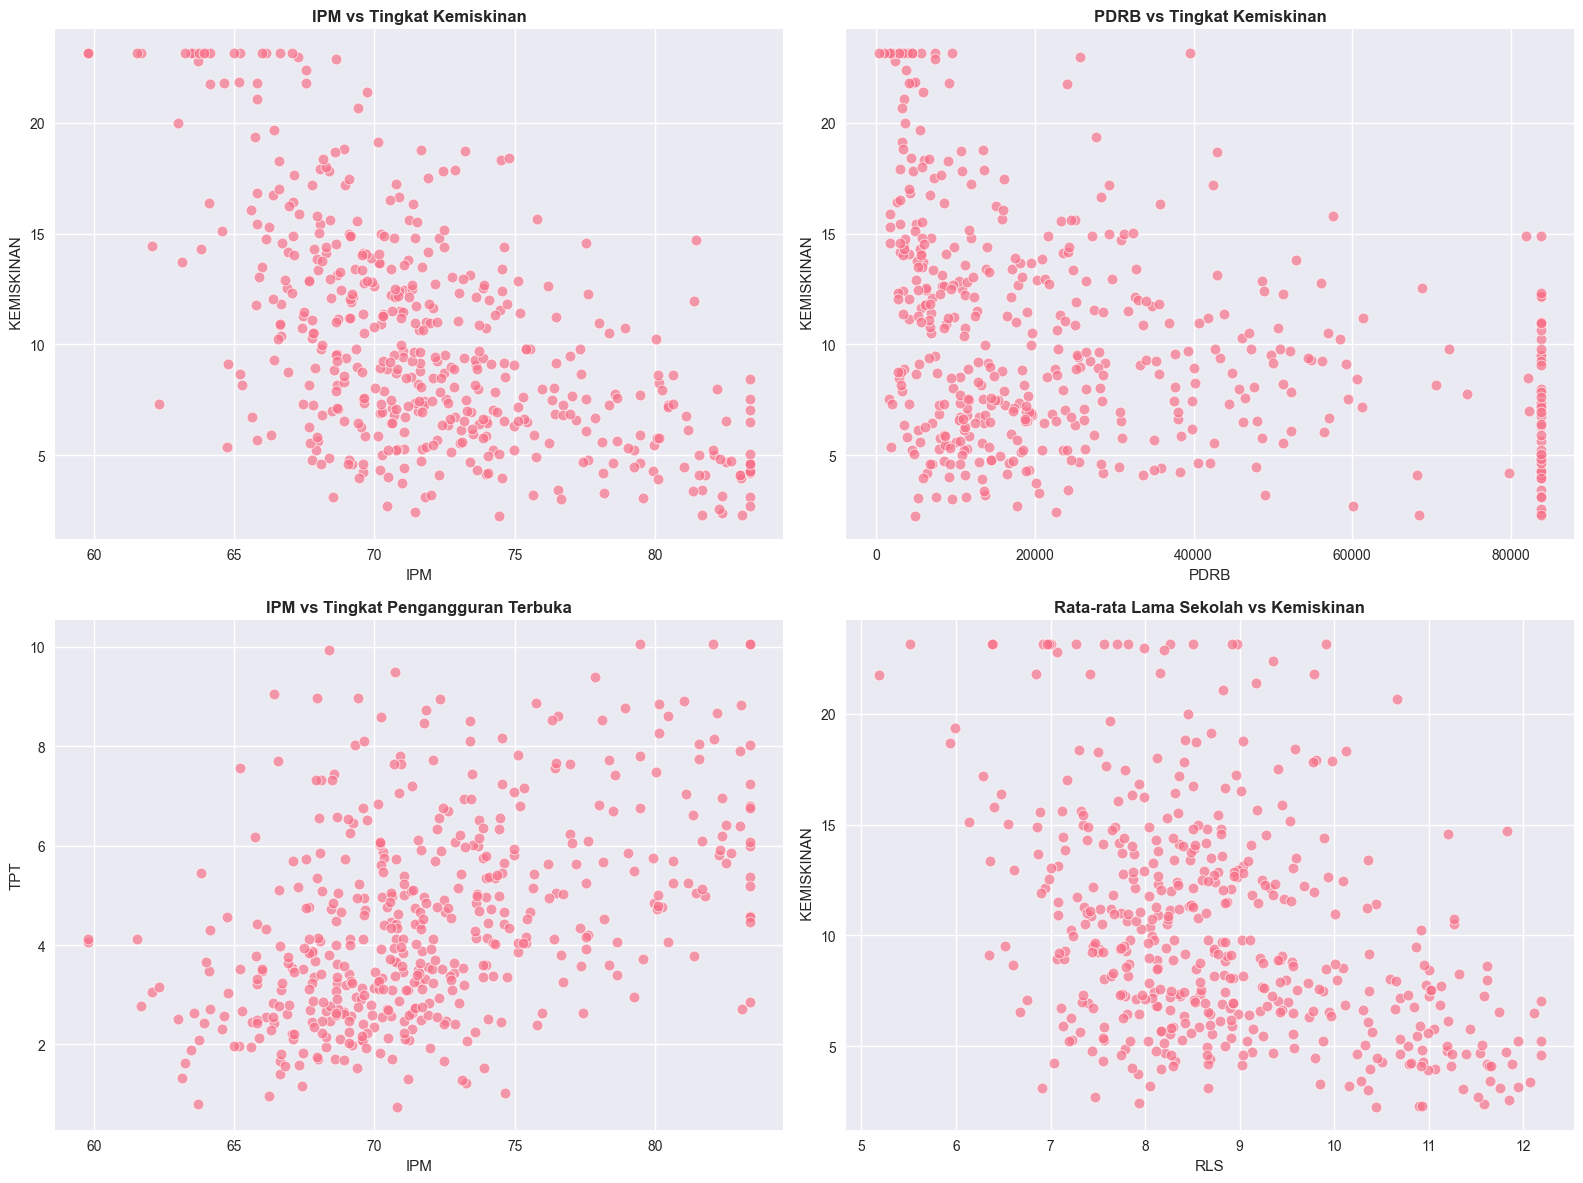

In [32]:
# Scatter plot hubungan penting 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# IPM vs Kemiskinan
sns.scatterplot(data=df_handled, x='IPM', y=' KEMISKINAN', ax=axes[0,0], alpha=0.7, s=60)
axes[0,0].set_title('IPM vs Tingkat Kemiskinan', fontweight='bold')

# PDRB vs Kemiskinan
sns.scatterplot(data=df_handled, x='PDRB', y=' KEMISKINAN', ax=axes[0,1], alpha=0.7, s=60)
axes[0,1].set_title('PDRB vs Tingkat Kemiskinan', fontweight='bold')

# IPM vs TPT (Tingkat Pengangguran Terbuka)
sns.scatterplot(data=df_handled, x='IPM', y='TPT', ax=axes[1,0], alpha=0.7, s=60)
axes[1,0].set_title('IPM vs Tingkat Pengangguran Terbuka', fontweight='bold')

# RLS vs Kemiskinan
sns.scatterplot(data=df_handled, x='RLS', y=' KEMISKINAN', ax=axes[1,1], alpha=0.7, s=60)
axes[1,1].set_title('Rata-rata Lama Sekolah vs Kemiskinan', fontweight='bold')

plt.tight_layout()
plt.show()

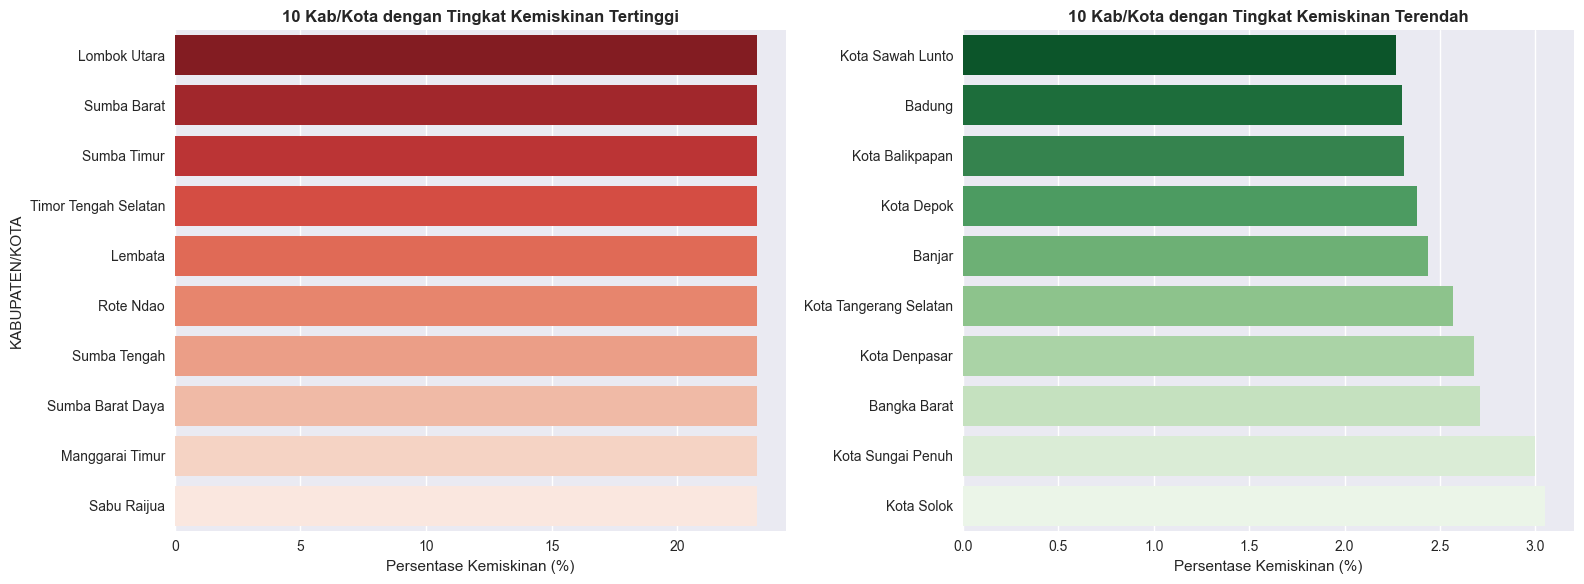

In [33]:
# Top 10 Kab/Kota dengan Kemiskinan Tertinggi & Terendah
top10_poor = df_handled.nlargest(10, ' KEMISKINAN')[['KABUPATEN/KOTA', ' KEMISKINAN']]
top10_rich = df_handled.nsmallest(10, ' KEMISKINAN')[['KABUPATEN/KOTA', ' KEMISKINAN']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top10_poor, y='KABUPATEN/KOTA', x=' KEMISKINAN', ax=axes[0], palette='Reds_r')
axes[0].set_title('10 Kab/Kota dengan Tingkat Kemiskinan Tertinggi', fontweight='bold')
axes[0].set_xlabel('Persentase Kemiskinan (%)')

sns.barplot(data=top10_rich, y='KABUPATEN/KOTA', x=' KEMISKINAN', ax=axes[1], palette='Greens_r')
axes[1].set_title('10 Kab/Kota dengan Tingkat Kemiskinan Terendah', fontweight='bold')
axes[1].set_xlabel('Persentase Kemiskinan (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### STANDARISASI DATA

In [34]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Memilih kolom numerik
numeric_cols = df.select_dtypes(include='number').columns

# Inisialisasi scaler
scaler = StandardScaler()

# Melakukan standarisasi
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Menampilkan hasil
df_scaled

,KABUPATEN/KOTA,KEMISKINAN,PDRB,IPM,TPT,RLS
0,Simeulue,1.514038,-0.959463,-0.798981,0.687955,0.746935
1,Aceh Singkil,1.756259,-0.948937,-0.380056,1.185504,-0.061439
2,Aceh Selatan,0.367919,-0.800895,-0.722447,0.125072,0.091497
3,Aceh Tenggara,0.436844,-0.828666,-0.196777,0.260767,0.950850
4,Aceh Timur,0.621956,-0.531667,-0.545209,1.783568,-0.228940
...,...,...,...,...,...,...
474,Teluk Wondama,2.547417,-1.006122,-2.085966,-0.859974,-1.102858
475,Teluk Bintuni,2.547417,0.481437,-1.213877,-0.483043,-0.199809
476,Manokwari,1.673550,-0.655878,0.238260,0.748264,-0.177961
477,Manokwari Selatan,2.547417,-1.038489,-2.110134,-0.178986,-1.328620


### membagi data training dan testing

In [ ]:
df.columns

Index(['KABUPATEN/KOTA', ' KEMISKINAN', 'PDRB', 'IPM', 'TPT', 'RLS'], dtype='object')

In [ ]:
#menentukan variabel x dan y
X = df_scaled.drop([' KEMISKINAN','KABUPATEN/KOTA' ], axis=1)
y = df_scaled[' KEMISKINAN']

##### y = variabel target (KEMISKINAN),    x = semua variabel lain selain KEMISKINAN

In [ ]:
#split data menjadi train dan test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data total :", len(X))
print("Jumlah data training :", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data total : 479
Jumlah data training : 383
Jumlah data testing : 96


### PEMODELAN

In [ ]:
# IMPORT MODEL

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
 # BUAT MODEL 
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# PREDIKSI
y_pred = model.predict(X_test)

# EVALUASI
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 0.6323906347428855
RMSE: 0.8274618303347342
R²  : 0.3374835520969225


n_estimators : Jumlah pohon, lebih banyak = lebih stabil
max_depth	: Maksimal kedalaman pohon (untuk kurangi overfitting)
min_samples_split : Minimum sampel agar node bisa di-split
min_samples_leaf : Sampel minimal pada daun pohon
max_features : Berapa fitur yang dipilih secara acak setiap spli

In [ ]:
# Tuning parameter

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

# PARAMETER RANGE UNTUK DICARI
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['auto', 'sqrt', 'log2']
}

# MODEL DASAR
rf = RandomForestRegressor(random_state=42)

# RANDOM SEARCH
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,          # jumlah kombinasi dicoba
    scoring='r2',       # karena regresi
    cv=5,               # 5-fold cross validation
    random_state=42,
    n_jobs=-1           # gunakan semua core CPU
)

# FIT KE DATA TRAINING
random_search.fit(X_train, y_train)

# TAMPILKAN PARAMETER TERBAIK
print("Best Parameters:", random_search.best_params_)

# MODEL TERBAIK
best_model = random_search.best_estimator_

# PREDIKSI DAN EVALUASI
y_pred_tuned = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred_tuned)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred_tuned)
r2 = r2_score(y_test, y_pred_tuned)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Best Parameters: {'max_depth': 16, 'max_features': 'log2', 'min_samples_leaf': 9, 'min_samples_split': 16, 'n_estimators': 114}
MAE : 0.6407532343684897
RMSE: 0.8172577611872182
R²  : 0.35372280271601375
